# Detection of Neonatal Jaundice — ResNet50 with YCbCr Skin Segmentation

**Dataset**: JAUNDICE IMAGE DATA — Kaggle (`/kaggle/input/jaundice-image-data/`)  
**Approach**: YCbCr skin segmentation + ResNet50 transfer learning  
**Paper**: Patravali et al. (2014) — *Skin Segmentation Using YCbCr and RGB Color Models*

---
### Pipeline
1. Import libraries
2. Load dataset and explore class distribution
3. Visualise sample images
4. Skin segmentation + preprocessing and data augmentation
5. Build ResNet50 model
6. Train the model (Phase 1 → Phase 2)
7. Evaluate and visualise results

## 1. Import Libraries

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.21.0


## 2. Load Dataset and Explore

In [3]:
# Dataset paths (Kaggle)
JAUNDICE_DIR = 'archive/jaundice'
NORMAL_DIR = 'archive/normal'

# Collect all image paths and labels
jaundice_images = [os.path.join(JAUNDICE_DIR, f) for f in os.listdir(JAUNDICE_DIR)]
normal_images   = [os.path.join(NORMAL_DIR,   f) for f in os.listdir(NORMAL_DIR)]

all_images = jaundice_images + normal_images
all_labels = ['jaundice'] * len(jaundice_images) + ['normal'] * len(normal_images)

# Build a DataFrame for easy handling
data = pd.DataFrame({'image_path': all_images, 'label': all_labels})
data = data.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print('=== Dataset Summary ===')
print(data['label'].value_counts())
print(f'\nTotal images: {len(data)}')

=== Dataset Summary ===
label
normal      560
jaundice    200
Name: count, dtype: int64

Total images: 760


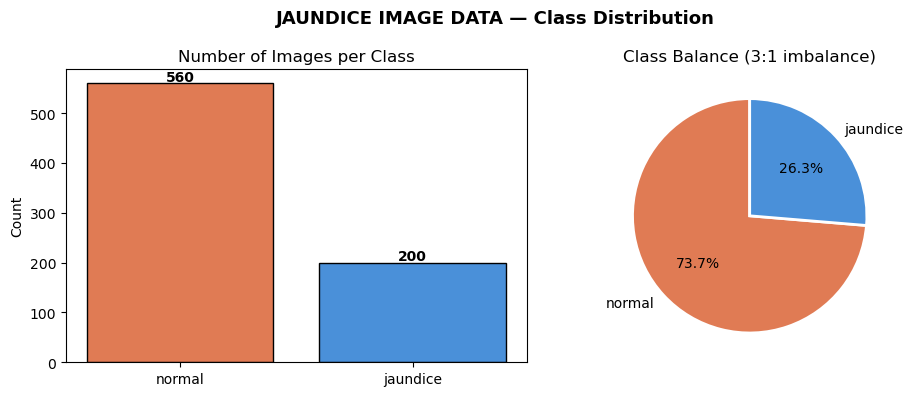

In [4]:
# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = data['label'].value_counts()
colors = ['#E07B54', '#4A90D9']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Number of Images per Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance (3:1 imbalance)')

plt.suptitle('JAUNDICE IMAGE DATA — Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Visualise Sample Images

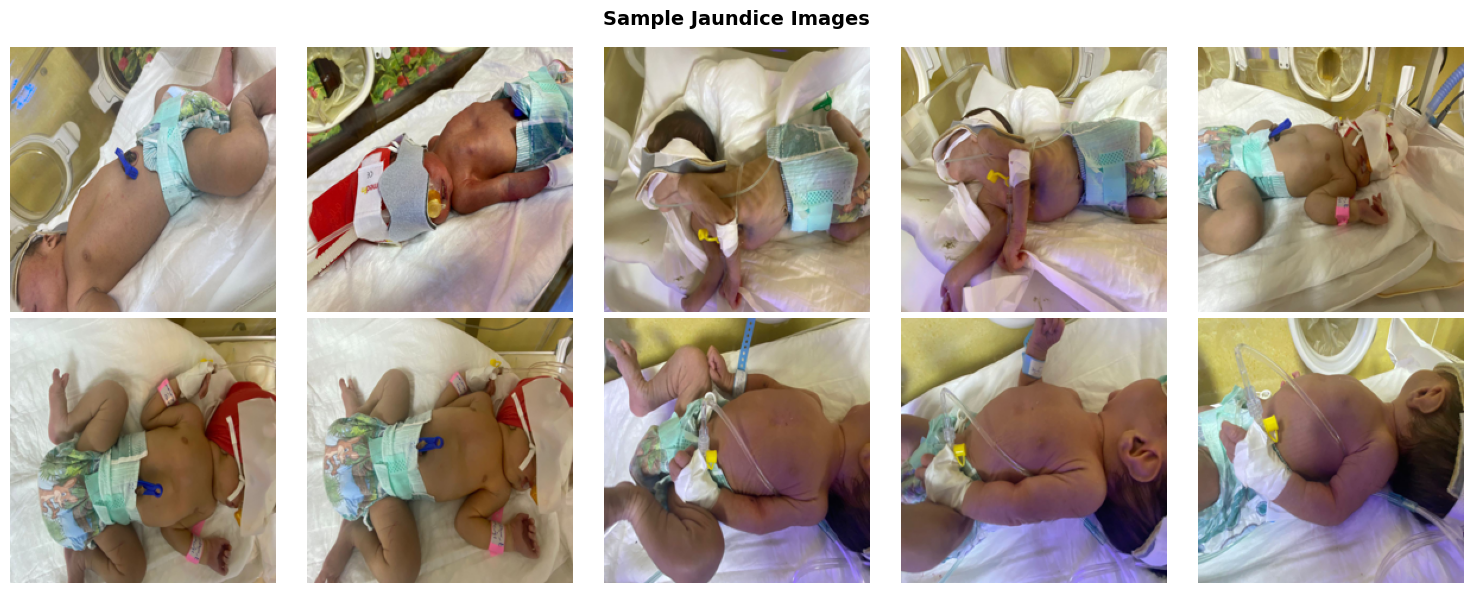

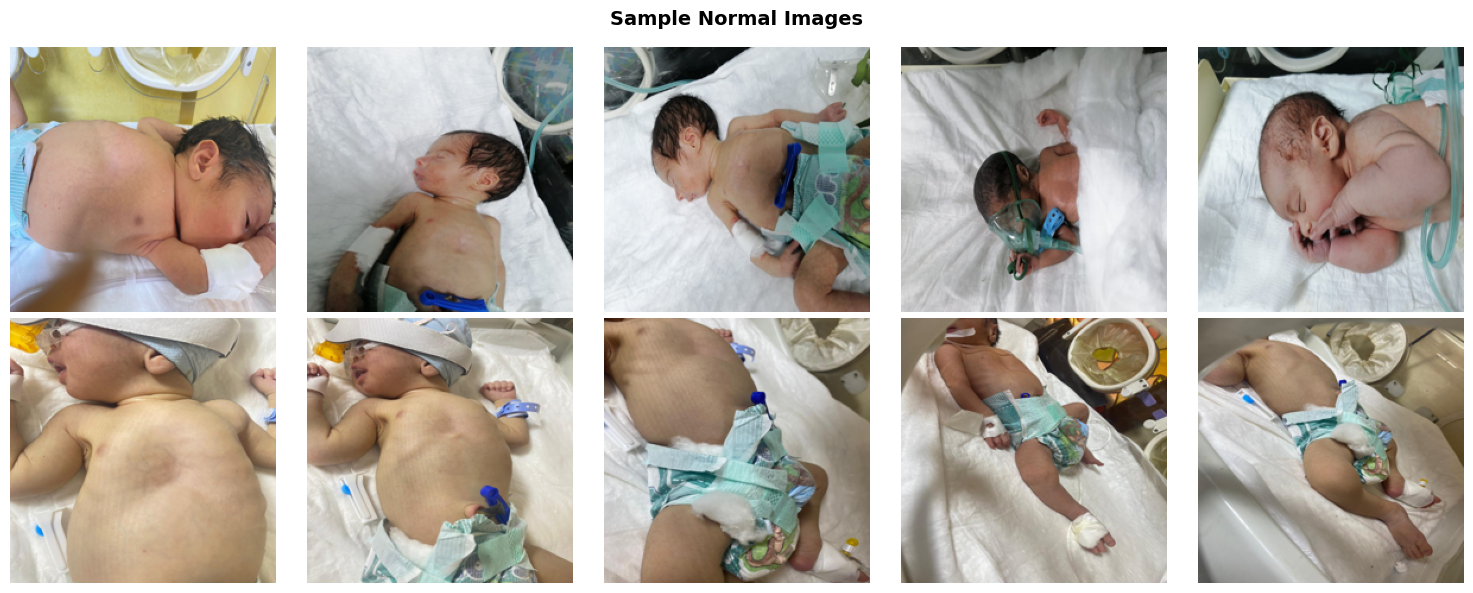

In [5]:
def visualize_samples(image_paths, title, rows=2, cols=5):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for ax, path in zip(axes.flat, image_paths[:rows * cols]):
        img = Image.open(path).resize((224, 224))
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_samples(jaundice_images, 'Sample Jaundice Images')
visualize_samples(normal_images,   'Sample Normal Images')

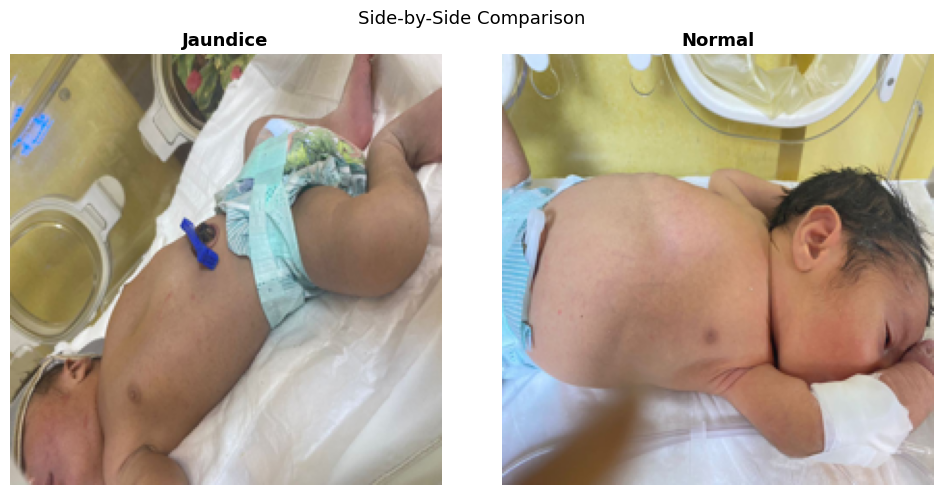

In [6]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, path, title in zip(axes,
                            [jaundice_images[0], normal_images[0]],
                            ['Jaundice', 'Normal']):
    ax.imshow(Image.open(path).resize((224, 224)))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')
plt.suptitle('Side-by-Side Comparison', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Skin Segmentation + Preprocessing and Data Augmentation

| Step | What it does |
|---|---|
| YCbCr skin segmentation | Zeroes out non-skin pixels so ResNet50 focuses only on skin |
| Resize to 224×224 | Required input size for ResNet50 |
| ResNet50 preprocess | Scales pixels to ImageNet mean/std that ResNet50 was trained with |
| Horizontal flip | Teaches the model orientation does not change the label |
| Rotation/zoom/shear | Handles different camera angles and distances |
| Brightness variation | Makes the model robust to different lighting conditions |
| Class weighting | Stops the model ignoring the minority Jaundice class |

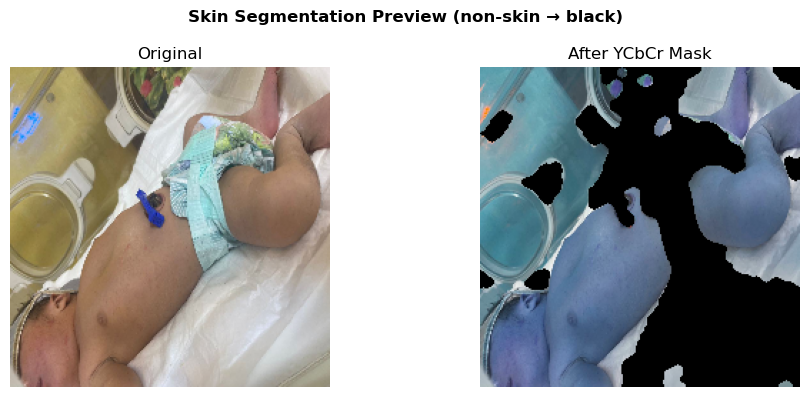

Skin segmentation function ready.


In [7]:
# ── YCbCr Skin Segmentation (Patravali et al. 2014) ─────────────────────────
# Thresholds from the paper: 77 ≤ Cb ≤ 127  and  133 ≤ Cr ≤ 173
# Non-skin pixels are set to zero so the model sees only the clinically
# relevant region (jaundice is a skin-colour change, not a background feature).

def ycbcr_skin_preprocess(img):
    """
    Applied by ImageDataGenerator as preprocessing_function.
    Receives a float32 image (0-255 range, RGB).
    Returns float32 image (0-255 range, RGB) with non-skin pixels zeroed,
    then scaled to ImageNet stats expected by ResNet50.
    """
    # Convert RGB float → BGR uint8 for OpenCV
    img_bgr = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2BGR)

    # Convert to YCbCr and threshold Cb / Cr channels
    ycbcr       = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
    _, Cr, Cb   = cv2.split(ycbcr)          # OpenCV YCrCb order: Y, Cr, Cb
    mask_cb     = cv2.inRange(Cb, 77,  127)
    mask_cr     = cv2.inRange(Cr, 133, 173)
    mask        = cv2.bitwise_and(mask_cb, mask_cr)

    # Morphological cleanup: fill holes then remove noise (paper §IV)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)

    # Apply mask: non-skin pixels → 0
    mask_3ch = np.stack([mask, mask, mask], axis=-1)
    img_masked = np.where(mask_3ch > 0, img, 0).astype(np.float32)

    # Apply ResNet50 preprocessing (subtracts ImageNet mean, no rescale needed)
    img_preprocessed = tf.keras.applications.resnet50.preprocess_input(img_masked)
    return img_preprocessed


# Quick visual check — original vs segmented
sample_bgr  = cv2.resize(cv2.imread(jaundice_images[0]), (224, 224))
sample_rgb  = cv2.cvtColor(sample_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
sample_seg  = ycbcr_skin_preprocess(sample_rgb.copy())
# Reverse preprocess_input for display (add back mean)
sample_disp = np.clip(sample_seg + [103.939, 116.779, 123.68], 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sample_rgb.astype(np.uint8));  axes[0].set_title('Original');           axes[0].axis('off')
axes[1].imshow(sample_disp);                  axes[1].set_title('After YCbCr Mask');   axes[1].axis('off')
plt.suptitle('Skin Segmentation Preview (non-skin → black)', fontweight='bold')
plt.tight_layout()
plt.show()
print('Skin segmentation function ready.')

In [8]:
# Compute class weights to handle the 3:1 imbalance
classes = np.array(['jaundice', 'normal'])
weights = compute_class_weight('balanced', classes=classes, y=data['label'].values)
class_weights = {0: weights[0], 1: weights[1]}

print('Class weights:')
for i, (cls, w) in enumerate(zip(classes, weights)):
    print(f'  {i} ({cls}): {w:.3f}')

Class weights:
  0 (jaundice): 1.900
  1 (normal): 0.679


In [9]:
# Training generator — with skin segmentation + augmentation
# NOTE: rescale is NOT set here because ycbcr_skin_preprocess handles
#       normalisation itself (applies ResNet50 preprocess_input internally).
train_datagen = ImageDataGenerator(
    preprocessing_function=ycbcr_skin_preprocess,  # ← skin segmentation
    validation_split=0.20,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

# Validation generator — skin segmentation only, no augmentation
val_datagen = ImageDataGenerator(
    preprocessing_function=ycbcr_skin_preprocess,  # ← same segmentation
    validation_split=0.20
)

train_generator = train_datagen.flow_from_dataframe(
    data,
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    seed=42
)

validation_generator = val_datagen.flow_from_dataframe(
    data,
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f'Training images  : {train_generator.n}')
print(f'Validation images: {validation_generator.n}')
print(f'Class mapping    : {train_generator.class_indices}')

Found 608 validated image filenames belonging to 2 classes.
Found 152 validated image filenames belonging to 2 classes.
Training images  : 608
Validation images: 152
Class mapping    : {'jaundice': 0, 'normal': 1}


## 5. Build the ResNet50 Model

**Architecture:**
```
Input (224×224×3)  ← skin-segmented image
  └── ResNet50 base (pretrained on ImageNet, frozen in Phase 1)
  └── GlobalAveragePooling2D
  └── Dense(256, ReLU) → BatchNorm → Dropout(0.5)
  └── Dense(1, Sigmoid) → output probability
```

**Two-phase training:**
- **Phase 1** — ResNet50 base frozen, only the new head trains (15 epochs).
  The head learns to read ResNet50's features for this specific task.
- **Phase 2** — Top 30 layers of ResNet50 unfrozen, whole model fine-tuned
  with a smaller learning rate (15 epochs). The high-level ResNet features
  adapt to the jaundice skin-tone signal.

In [10]:
def build_resnet_model(input_shape=(224, 224, 3)):
    # Load ResNet50 pretrained on ImageNet, without the top classification layer
    base_model = ResNet50(weights='imagenet', include_top=False,
                          input_shape=input_shape)
    base_model.trainable = False   # freeze all base layers for Phase 1

    # Add a small classification head on top
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)                 
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output,
                  name='Jaundice_ResNet50')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model

model, base_model = build_resnet_model()

# Show only the trainable parameter count (base is frozen in Phase 1)
trainable     = sum(tf.size(w).numpy() for w in model.trainable_weights)
non_trainable = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
print(f'Phase 1 — Trainable params    : {trainable:,}  (head only)')
print(f'Phase 1 — Non-trainable params: {non_trainable:,}  (ResNet50 base, frozen)')

Phase 1 — Trainable params    : 525,313  (head only)
Phase 1 — Non-trainable params: 23,588,224  (ResNet50 base, frozen)


## 6. Train the Model

In [11]:
# ── Phase 1: Train the head only (base frozen) ───────────────────────────────
# The ResNet50 base already knows how to extract visual features from ImageNet.
# We first let the new Dense head learn to interpret those features for
# jaundice detection, without disturbing the base weights.

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_resnet_phase1.keras', monitor='val_loss',
                    save_best_only=True, verbose=0)
]

print('=== Phase 1: Training head only ===')
history_phase1 = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=callbacks_phase1,
    verbose=1
)

=== Phase 1: Training head only ===
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - accuracy: 0.5806 - loss: 0.8746 - val_accuracy: 0.7566 - val_loss: 1.0127 - learning_rate: 0.0010
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.6908 - loss: 0.6137 - val_accuracy: 0.4342 - val_loss: 1.7277 - learning_rate: 0.0010
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.6776 - loss: 0.5751 - val_accuracy: 0.7763 - val_loss: 0.4696 - learning_rate: 0.0010
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.7434 - loss: 0.5344 - val_accuracy: 0.7105 - val_loss: 0.5799 - learning_rate: 0.0010
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.7122 - loss: 0.5676 - val_accuracy: 0.7566 - val_loss: 0.8405 - learning_rate: 0.0010
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.7434 - loss: 0.5349 - val_accuracy: 0.7500 - val_loss: 0.5267 - learning_rate: 0.0010
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7

In [12]:
# ── Phase 2: Unfreeze top 30 ResNet50 layers and fine-tune ──────────────────
# The head is now trained and stable. We unfreeze the last 30 layers of
# ResNet50 so the model can adapt its high-level features to recognise the
# specific yellowish skin-tone signal of jaundice.
# Learning rate is reduced 10x to avoid overwriting the features learned in Phase 1.

# Unfreeze the top 50 layers of the base model
for layer in base_model.layers[:-50]:
    layer.trainable = False
for layer in base_model.layers[-50:]:
    layer.trainable = True

# Recompile with a much smaller learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

trainable_p2 = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Phase 2 — Trainable params: {trainable_p2:,}  (head + top 30 ResNet layers)')

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=5, min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_resnet_phase2.keras', monitor='val_loss',
                    save_best_only=True, verbose=0)
]

print('\n=== Phase 2: Fine-tuning top 30 ResNet layers ===')
history_phase2 = model.fit(
    train_generator,
    epochs=25,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=callbacks_phase2,
    verbose=1
)

Phase 2 — Trainable params: 17,475,841  (head + top 30 ResNet layers)

=== Phase 2: Fine-tuning top 30 ResNet layers ===
Epoch 1/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.7632 - loss: 0.4725 - val_accuracy: 0.7961 - val_loss: 0.5506 - learning_rate: 5.0000e-05
Epoch 2/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.7895 - loss: 0.4499 - val_accuracy: 0.7566 - val_loss: 0.8432 - learning_rate: 5.0000e-05
Epoch 3/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.8059 - loss: 0.3698 - val_accuracy: 0.7829 - val_loss: 0.6647 - learning_rate: 5.0000e-05
Epoch 4/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.8059 - loss: 0.3425 - val_accuracy: 0.8487 - val_loss: 0.4454 - learning_rate: 5.0000e-05
Epoch 5/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.8470 - loss: 0.2787 - val_accuracy: 0.8158 - val_loss: 0.4029 - learning_rate: 5.0000e-05
Epoch 6/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.8586 - loss: 0.2717 - val_accuracy: 0.8289 - 

## 7. Evaluate and Visualise Results

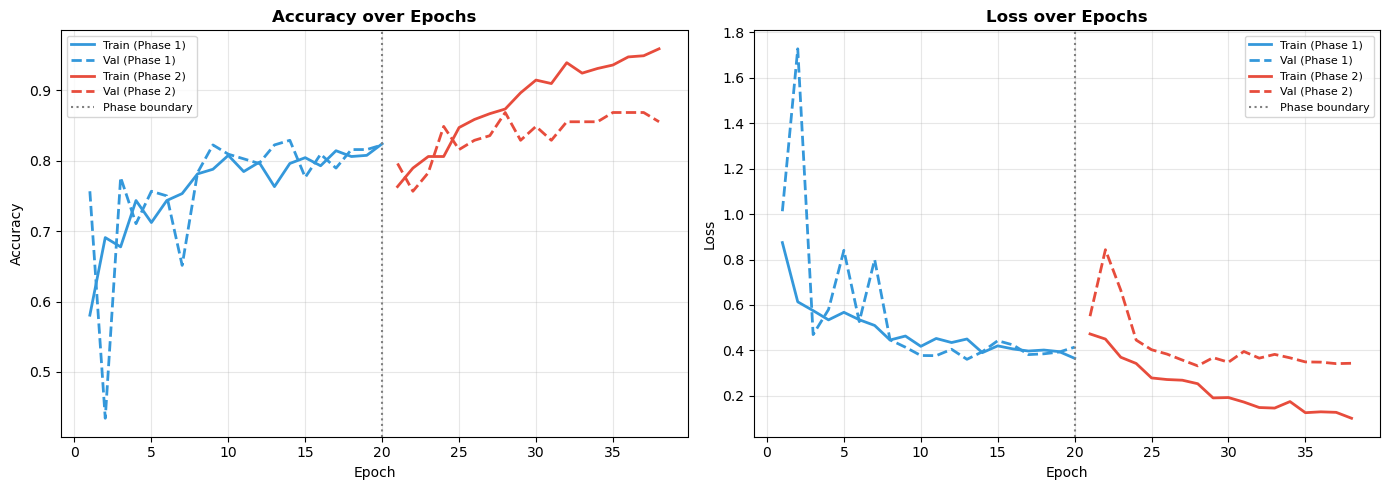

In [13]:
# Plot training curves — combine both phases on one chart
acc1  = history_phase1.history['accuracy']
acc2  = history_phase2.history['accuracy']
vacc1 = history_phase1.history['val_accuracy']
vacc2 = history_phase2.history['val_accuracy']
loss1  = history_phase1.history['loss']
loss2  = history_phase2.history['loss']
vloss1 = history_phase1.history['val_loss']
vloss2 = history_phase2.history['val_loss']

e1 = len(acc1)   # where Phase 1 ends

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, train1, val1, train2, val2, ylabel, title in zip(
    axes,
    [acc1, loss1], [vacc1, vloss1],
    [acc2, loss2], [vacc2, vloss2],
    ['Accuracy', 'Loss'],
    ['Accuracy over Epochs', 'Loss over Epochs']
):
    x1 = range(1, e1 + 1)
    x2 = range(e1 + 1, e1 + len(train2) + 1)
    ax.plot(x1, train1, '#3498DB', linewidth=2, label='Train (Phase 1)')
    ax.plot(x1, val1,   '#3498DB', linewidth=2, linestyle='--', label='Val (Phase 1)')
    ax.plot(x2, train2, '#E74C3C', linewidth=2, label='Train (Phase 2)')
    ax.plot(x2, val2,   '#E74C3C', linewidth=2, linestyle='--', label='Val (Phase 2)')
    ax.axvline(e1, color='gray', linestyle=':', linewidth=1.5, label='Phase boundary')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Get predictions on the validation set
validation_generator.reset()
y_prob = model.predict(validation_generator, verbose=0).flatten()
y_pred = (y_prob >= 0.40).astype(int)
y_true = validation_generator.classes

# Class indices: jaundice=0, normal=1
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=['jaundice', 'normal']))

Classification Report:
              precision    recall  f1-score   support

    jaundice       0.77      0.54      0.63        37
      normal       0.87      0.95      0.90       115

    accuracy                           0.85       152
   macro avg       0.82      0.74      0.77       152
weighted avg       0.84      0.85      0.84       152



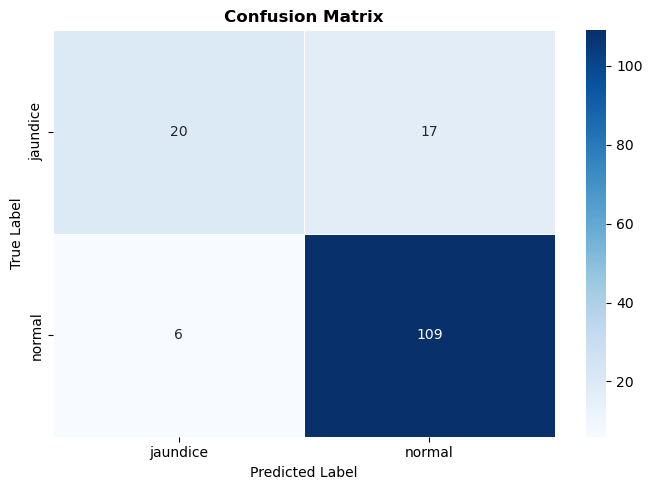

True Positives  (Jaundice correctly detected): 109
False Negatives (Jaundice missed):             6
True Negatives  (Normal correctly identified): 20
False Positives (Normal flagged as Jaundice):  17


In [15]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['jaundice', 'normal'],
            yticklabels=['jaundice', 'normal'],
            linewidths=0.5)
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Quick read of the matrix
tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (Jaundice correctly detected): {tp}')
print(f'False Negatives (Jaundice missed):             {fn}')
print(f'True Negatives  (Normal correctly identified): {tn}')
print(f'False Positives (Normal flagged as Jaundice):  {fp}')

In [16]:
model.save("jaundice_model.h5")
